<a href="https://colab.research.google.com/github/yeshaa23/FEC5026231125/blob/main/QUIZ_PBA_5026231125_Ayesha_Hana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍🩺 QUIZ PBA
**Rabu, 15 April 2026**

## 🔹 1. Environment Setup
```python
!pip install datasets transformers spacy matplotlib
!python -m spacy download en_core_web_sm
```

In [ ]:
!pip install datasets transformers spacy matplotlib
!pip install -q gnews newspaper3k lxml_html_clean pandas openpyxl spacy textblob scikit-learn matplotlib wordcloud
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install -U datasets

In [ ]:
# import library
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from textblob import TextBlob
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer

## 🔹 2. Load Dataset (Climate Change NER)

In [ ]:
from datasets import load_dataset

# Force download from Hugging Face hub directly (avoid cache)
dataset = load_dataset("ibm-research/Climate-Change-NER", trust_remote_code=True, download_mode="force_redownload")

print(dataset)
print(dataset["train"][0].keys())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibm-research/Climate-Change-NER' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ibm-research/Climate-Change-NER' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your sessi

en.train.txt: 0.00B [00:00, ?B/s]

en.val.txt: 0.00B [00:00, ?B/s]

en.test.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/33420 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6711 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6104 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 33420
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 6711
    })
    test: Dataset({
        features: ['text'],
        num_rows: 6104
    })
})
dict_keys(['text'])


In [ ]:
for i in range(10):
    print(dataset["train"][i])

{'text': '-DOCSTART- -X- O O 0b67946e55e9780a2939fcfccbcfb167'}
{'text': ''}
{'text': 'The O'}
{'text': 'outcomes O'}
{'text': 'of O'}
{'text': 'the O'}
{'text': 'sensitivity O'}
{'text': 'analysis O'}
{'text': 'framework O'}
{'text': 'suggest O'}


In [ ]:
# mengubah data mentah per token menjadi teks utuh
# ambil token pertama dari setiap baris
# kalau ada baris kosong dianggap sebagai pemisah kalimat/dokumen

def parse_conll_format(data_split):
    documents = []
    tokens = []

    for row in data_split:
        line = row["text"]

        # lewati penanda awal dokumen
        if line.startswith("-DOCSTART-"):
            continue

        if line.strip() == "":
            if tokens:
                documents.append(" ".join(tokens))
                tokens = []
            continue

        # pecah baris berdasarkan spasi
        parts = line.split()

        # jika ada isi, ambil token pertama sebagai kata
        if len(parts) > 0:
            token = parts[0]
            tokens.append(token)

    if tokens:
        documents.append(" ".join(tokens))

    return documents

In [ ]:
# parse split train jadi daftar teks
parsed_train_texts = parse_conll_format(dataset["train"])
print("Jumlah teks hasil parsing:", len(parsed_train_texts))
for i, text in enumerate(parsed_train_texts[:5], start=1):
    print(f"\nContoh teks {i}:")
    print(text[:500])

Jumlah teks hasil parsing: 1006

Contoh teks 1:
The outcomes of the sensitivity analysis framework suggest that flood risk can vary dramatically as a result of possible change scenarios .

Contoh teks 2:
The risk components that have not received much attention ( e.g. changes in dike systems and in vulnerability ) may mask the influence of climate change that is often investigated component .

Contoh teks 3:
A parameterization of vertical diffusivity in ocean general circulation models has been implemented in the ocean model component of the Community Climate System Model ( CCSM ) .

Contoh teks 4:
The parameterization represents the dynamics of the mixing in the abyssal ocean arising from the breaking of internal waves generated by the tides forcing stratified flow over rough topography .

Contoh teks 5:
Diapycnal mixing in the ocean is thought to be one of the primary controls on the meridional overturning circulation and the poleward heat transport by the ocean .


In [ ]:
# ubah hasil parsing jadi dataframe
train_df = pd.DataFrame({"text": parsed_train_texts})
train_df = train_df[train_df["text"].str.strip() != ""].reset_index(drop=True)
train_df.head()

,text
0,The outcomes of the sensitivity analysis frame...
1,The risk components that have not received muc...
2,A parameterization of vertical diffusivity in ...
3,The parameterization represents the dynamics o...
4,Diapycnal mixing in the ocean is thought to be...


## 3. Scrapping 5 artikel (water scarce)

In [ ]:
# filter teks yang relevan (drought/water scarce)

keywords = [
    "drought",
    "water scarcity",
    "water scarce",
    "scarcity",
    "dry"
]

def contains_keyword(text):
    text = text.lower()
    return any(keyword in text for keyword in keywords)

filtered_df = train_df[train_df["text"].apply(contains_keyword)].copy().reset_index(drop=True)
print("Jumlah teks relevan:", len(filtered_df))
filtered_df.head()

Jumlah teks relevan: 28


,text
0,"In addition , isotope analysis also shows that..."
1,The detailed field survey to assess the deposi...
2,Transpiration of the boreal forest ecosystem m...
3,Landscape - level processes such as fire regim...
4,We analyzed the spatiotemporal evolution of dr...


In [ ]:
# ambil 5 artikel
sample_df = filtered_df.head(5).copy().reset_index(drop=True)
sample_df["article_id"] = [f"Artikel_{i+1}" for i in range(len(sample_df))]
sample_df = sample_df[["article_id", "text"]]
sample_df

,article_id,text
0,Artikel_1,"In addition , isotope analysis also shows that..."
1,Artikel_2,The detailed field survey to assess the deposi...
2,Artikel_3,Transpiration of the boreal forest ecosystem m...
3,Artikel_4,Landscape - level processes such as fire regim...
4,Artikel_5,We analyzed the spatiotemporal evolution of dr...


In [ ]:
scraped_df = sample_df.copy()
scraped_df

,article_id,text
0,Artikel_1,"In addition , isotope analysis also shows that..."
1,Artikel_2,The detailed field survey to assess the deposi...
2,Artikel_3,Transpiration of the boreal forest ecosystem m...
3,Artikel_4,Landscape - level processes such as fire regim...
4,Artikel_5,We analyzed the spatiotemporal evolution of dr...


## SOAL 1
Melakukan seperti climate IBM (cari NER)nya

In [ ]:
!pip install -q transformers torch spacy textblob scikit-learn matplotlib

In [ ]:
# import library
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy
from spacy import displacy
from IPython.display import display, HTML

from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# cek dataframe hasil 5 artikel
print(scraped_df.head())
print(scraped_df.columns)

  article_id                                               text
0  Artikel_1  In addition , isotope analysis also shows that...
1  Artikel_2  The detailed field survey to assess the deposi...
2  Artikel_3  Transpiration of the boreal forest ecosystem m...
3  Artikel_4  Landscape - level processes such as fire regim...
4  Artikel_5  We analyzed the spatiotemporal evolution of dr...
Index(['article_id', 'text'], dtype='object')


### Load model NER

In [ ]:
model_name = "dslim/bert-base-NER"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp_ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
text = scraped_df.loc[0, "text"]
entities = nlp_ner(text)

entities[:10]

[]

### Visualisasi NER

In [ ]:
doc_data = {
    "text": text,
    "ents": [
        {"start": e["start"], "end": e["end"], "label": e["entity_group"]}
        for e in entities
    ],
    "title": None,
}

displacy.render(doc_data, style="ent", manual=True, jupyter=True)

In [ ]:
def visualize_ner(text):
    entities = nlp_ner(text)

    doc_data = {
        "text": text,
        "ents": [
            {"start": e["start"], "end": e["end"], "label": e["entity_group"]}
            for e in entities
        ],
        "title": None,
    }

    return displacy.render(doc_data, style="ent", manual=True, jupyter=True)

In [ ]:
# buat kolom hasil NER
def perform_ner(text):
    try:
        results = nlp_ner(text)
        return ", ".join([f"{r['word']} ({r['entity_group']})" for r in results])
    except:
        return ""

In [ ]:
scraped_df["ner_results"] = scraped_df["text"].apply(perform_ner)
scraped_df[["article_id", "ner_results"]]

,article_id,ner_results
0,Artikel_1,
1,Artikel_2,
2,Artikel_3,
3,Artikel_4,Proteaceae (MISC)
4,Artikel_5,"China (LOC), Mann (MISC), Kendall (MISC)"


In [ ]:
# buat tabel entitas

In [ ]:
all_entities = []

for _, row in scraped_df.iterrows():
    results = nlp_ner(row["text"])

    for r in results:
        all_entities.append({
            "article_id": row["article_id"],
            "entity": r["word"],
            "label": r["entity_group"]
        })

entities_df = pd.DataFrame(all_entities)
entities_df.head(20)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,article_id,entity,label
0,Artikel_4,Proteaceae,MISC
1,Artikel_5,China,LOC
2,Artikel_5,Mann,MISC
3,Artikel_5,Kendall,MISC


### Frekuensi entitas

In [ ]:
if not entities_df.empty:
    entity_freq_df = (
        entities_df.groupby(["entity", "label"])
        .size()
        .reset_index(name="frequency")
        .sort_values(by="frequency", ascending=False)
        .reset_index(drop=True)
    )
else:
    entity_freq_df = pd.DataFrame(columns=["entity", "label", "frequency"])

entity_freq_df.head(20)

,entity,label,frequency
0,China,LOC,1
1,Kendall,MISC,1
2,Mann,MISC,1
3,Proteaceae,MISC,1


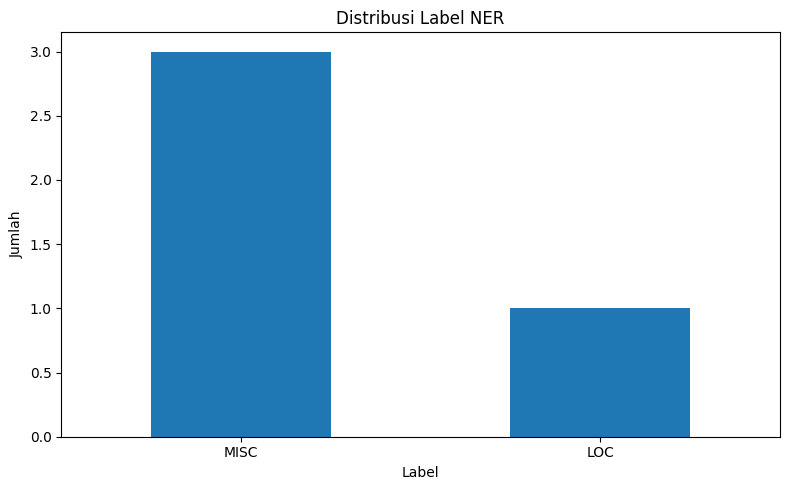

In [ ]:
# visualisasi jumlah tabel entitas

if not entities_df.empty:
    label_counts = entities_df["label"].value_counts()

    plt.figure(figsize=(8, 5))
    label_counts.plot(kind="bar")
    plt.title("Distribusi Label NER")
    plt.xlabel("Label")
    plt.ylabel("Jumlah")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada entitas yang terdeteksi.")

In [ ]:
# visualisasi NER per artikel
for i, row in scraped_df.iterrows():
    print(f"\n=== {row['article_id']} ===")
    visualize_ner(row["text"])


=== Artikel_1 ===



=== Artikel_2 ===



=== Artikel_3 ===



=== Artikel_4 ===



=== Artikel_5 ===


## SOAL 2
Lakukan sentimen analysis menggunakan textblob

In [ ]:
def analyze_sentiment_textblob(text):
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

def categorize_sentiment(score):
    if score > 0:
        return "Positif"
    elif score < 0:
        return "Negatif"
    else:
        return "Netral"

scraped_df["sentiment_score"] = scraped_df["text"].apply(analyze_sentiment_textblob)
scraped_df["sentiment_label"] = scraped_df["sentiment_score"].apply(categorize_sentiment)

scraped_df[["article_id", "sentiment_score", "sentiment_label"]]

,article_id,sentiment_score,sentiment_label
0,Artikel_1,-0.083333,Negatif
1,Artikel_2,0.166667,Positif
2,Artikel_3,-0.056190,Negatif
3,Artikel_4,0.000000,Netral
4,Artikel_5,0.160000,Positif


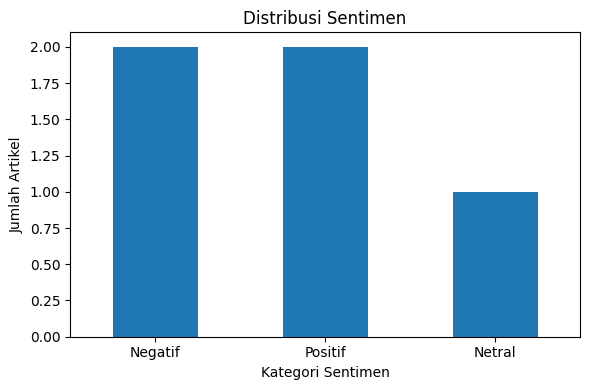

In [ ]:
# visualisasi hasil sentimen
sentiment_counts = scraped_df["sentiment_label"].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind="bar")
plt.title("Distribusi Sentimen")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Artikel")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## SOAL 3
Lakukan analisa TF-IDF sederhana

In [ ]:
# preprocessing teks untuk tfidf
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

scraped_df["clean_text"] = scraped_df["text"].apply(clean_text)

scraped_df[["article_id", "clean_text"]].head()

,article_id,clean_text
0,Artikel_1,in addition isotope analysis also shows that c...
1,Artikel_2,the detailed field survey to assess the deposi...
2,Artikel_3,transpiration of the boreal forest ecosystem m...
3,Artikel_4,landscape level processes such as fire regimes...
4,Artikel_5,we analyzed the spatiotemporal evolution of dr...


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=100,
    ngram_range=(1, 1)
)

X_tfidf = tfidf_vectorizer.fit_transform(scraped_df["clean_text"])

print("Shape TF-IDF:", X_tfidf.shape)

Shape TF-IDF: (5, 88)


### Term dan skor rata-rata TF-IDF

In [ ]:
terms = tfidf_vectorizer.get_feature_names_out()
mean_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

tfidf_results = pd.DataFrame({
    "term": terms,
    "mean_tfidf_score": mean_scores
}).sort_values(by="mean_tfidf_score", ascending=False).reset_index(drop=True)

tfidf_results.head(20)

,term,mean_tfidf_score
0,conditions,0.102559
1,dry,0.098626
2,sediment,0.091527
3,survey,0.091527
4,using,0.085212
5,level,0.077036
6,summer,0.076480
7,drought,0.070733
8,method,0.065732
9,groups,0.052251


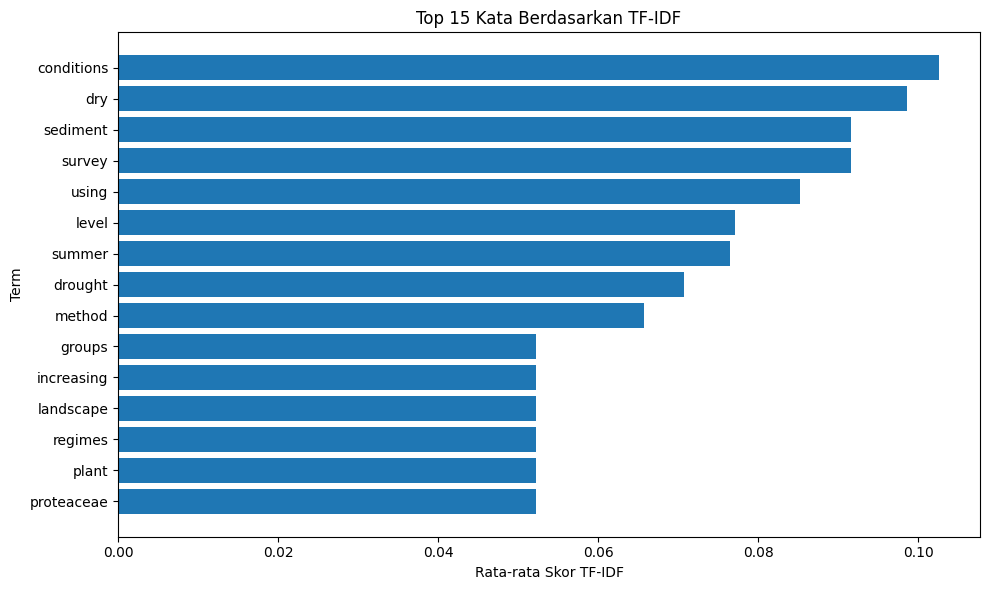

In [ ]:
# visualisasi
top_15 = tfidf_results.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15["term"][::-1], top_15["mean_tfidf_score"][::-1])
plt.title("Top 15 Kata Berdasarkan TF-IDF")
plt.xlabel("Rata-rata Skor TF-IDF")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [ ]:
# tabel TF-IDF per artikel
tfidf_per_article_df = pd.DataFrame(X_tfidf.toarray(), columns=terms)
tfidf_per_article_df.insert(0, "article_id", scraped_df["article_id"])
tfidf_per_article_df.head()

,article_id,activities,addition,addressed,affecting,agriculture,analysis,analyzed,aquaculture,assess,...,threats,transpiration,trees,trend,typical,using,vegetation,water,week,zone
0,Artikel_1,0.222197,0.222197,0.000000,0.000000,0.222197,0.222197,0.000000,0.222197,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.222197,0.000000,0.000000,0.000000,0.000000,0.000000
1,Artikel_2,0.000000,0.000000,0.228818,0.000000,0.000000,0.000000,0.000000,0.000000,0.228818,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.153242,0.000000,0.000000,0.000000,0.000000
2,Artikel_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.191201,0.191201,0.000000,0.000000,0.128049,0.000000,0.191201,0.000000,0.191201
3,Artikel_4,0.000000,0.000000,0.000000,0.261257,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.261257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Artikel_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.216162,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.216162,0.000000,0.144767,0.216162,0.000000,0.216162,0.000000


## Hasil akhir

In [ ]:
hasil_akhir_df = scraped_df[[
    "article_id",
    "text",
    "ner_results",
    "sentiment_score",
    "sentiment_label"
]].copy()

hasil_akhir_df

,article_id,text,ner_results,sentiment_score,sentiment_label
0,Artikel_1,"In addition , isotope analysis also shows that...",,-0.083333,Negatif
1,Artikel_2,The detailed field survey to assess the deposi...,,0.166667,Positif
2,Artikel_3,Transpiration of the boreal forest ecosystem m...,,-0.056190,Negatif
3,Artikel_4,Landscape - level processes such as fire regim...,Proteaceae (MISC),0.000000,Netral
4,Artikel_5,We analyzed the spatiotemporal evolution of dr...,"China (LOC), Mann (MISC), Kendall (MISC)",0.160000,Positif
